In [285]:
import pandas as pd
import numpy as np

In [286]:
import pandas as pd

df = pd.read_csv("../dataset/train.csv")

print(df.shape)
df.head()

(404290, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [287]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [288]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [289]:
df = df.dropna().reset_index(drop=True)

In [290]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [291]:
df['is_duplicate'].value_counts()

is_duplicate
0    255024
1    149263
Name: count, dtype: int64

In [292]:
df['is_duplicate'].value_counts(normalize=True)*100

is_duplicate
0    63.079941
1    36.920059
Name: proportion, dtype: float64

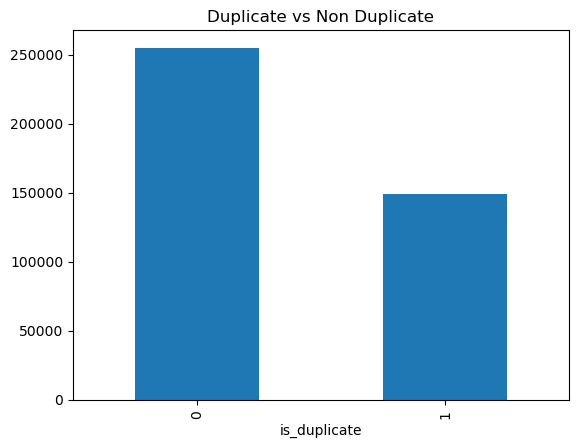

In [293]:
import matplotlib.pyplot as plt

df['is_duplicate'].value_counts().plot(
    kind='bar'
)

plt.title("Duplicate vs Non Duplicate")
plt.show()

In [294]:
qids = pd.Series(
    df['qid1'].tolist() +
    df['qid2'].tolist()
)

print("Unique Questions:", qids.nunique())

Unique Questions: 537929


In [295]:
df['q1_len'] = df['question1'].str.len()
df['q2_len'] = df['question2'].str.len()

In [296]:
df[['q1_len','q2_len']].describe()

,q1_len,q2_len
count,404287.000000,404287.000000
mean,59.536997,60.108507
std,29.940553,33.863588
min,1.000000,1.000000
25%,39.000000,39.000000
50%,52.000000,51.000000
75%,72.000000,72.000000
max,623.000000,1169.000000


In [297]:
df['q1_num_words'] = df['question1'].apply(
    lambda x: len(str(x).split())
)

df['q2_num_words'] = df['question2'].apply(
    lambda x: len(str(x).split())
)

In [298]:
df[['q1_num_words',
    'q2_num_words']].describe()

,q1_num_words,q2_num_words
count,404287.000000,404287.000000
mean,10.942256,11.182017
std,5.428812,6.305210
min,1.000000,1.000000
25%,7.000000,7.000000
50%,10.000000,10.000000
75%,13.000000,13.000000
max,125.000000,237.000000


In [299]:
def common_words(row):

    w1 = set(
        str(row['question1']).lower().split()
    )

    w2 = set(
        str(row['question2']).lower().split()
    )

    return len(w1.intersection(w2))

In [300]:
df['common_words'] = df.apply(
    common_words,
    axis=1
)

df[['question1',
     'question2',
     'common_words']].head()

,question1,question2,common_words
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,10
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,4
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,4
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,2


In [301]:
def word_share(row):

    w1 = set(
        str(row['question1']).lower().split()
    )

    w2 = set(
        str(row['question2']).lower().split()
    )

    if len(w1)+len(w2)==0:
        return 0

    return len(w1.intersection(w2)) / (
        len(w1)+len(w2)
    )

In [302]:
df['word_share'] = df.apply(
    word_share,
    axis=1
)

<Axes: xlabel='is_duplicate', ylabel='word_share'>

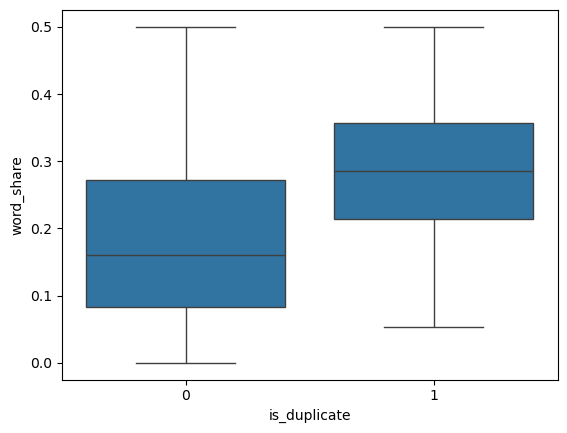

In [303]:
import seaborn as sns

sns.boxplot(
    x='is_duplicate',
    y='word_share',
    data=df.sample(10000)
)

In [304]:
df.dropna(inplace=True)

df['is_duplicate'].value_counts()

df['q1_len'] = df['question1'].str.len()
df['q2_len'] = df['question2'].str.len()

df['q1_num_words'] = df['question1'].apply(lambda x: len(str(x).split()))
df['q2_num_words'] = df['question2'].apply(lambda x: len(str(x).split()))

In [305]:
df['is_duplicate'].value_counts()

df[['q1_len','q2_len']].describe()

df[['q1_num_words','q2_num_words']].describe()

,q1_num_words,q2_num_words
count,404287.000000,404287.000000
mean,10.942256,11.182017
std,5.428812,6.305210
min,1.000000,1.000000
25%,7.000000,7.000000
50%,10.000000,10.000000
75%,13.000000,13.000000
max,125.000000,237.000000


In [306]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

STOP_WORDS = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhavy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [307]:
def token_features_fetch(row):

    q1 = str(row['question1']).lower()
    q2 = str(row['question2']).lower()

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return [0.0]*8

    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    common_word_count = len(q1_words & q2_words)
    common_stop_count = len(q1_stops & q2_stops)
    common_token_count = len(set(q1_tokens) & set(q2_tokens))

    features = []

    features.append(common_word_count/(min(len(q1_words),len(q2_words))+0.0001))
    features.append(common_word_count/(max(len(q1_words),len(q2_words))+0.0001))

    features.append(common_stop_count/(min(len(q1_stops),len(q2_stops))+0.0001))
    features.append(common_stop_count/(max(len(q1_stops),len(q2_stops))+0.0001))

    features.append(common_token_count/(min(len(q1_tokens),len(q2_tokens))+0.0001))
    features.append(common_token_count/(max(len(q1_tokens),len(q2_tokens))+0.0001))

    features.append(int(q1_tokens[0] == q2_tokens[0]))
    features.append(int(q1_tokens[-1] == q2_tokens[-1]))

    return features

In [308]:
token_features = df.apply(
    token_features_fetch,
    axis=1
)

In [309]:
df["cwc_min"] = token_features.apply(lambda x:x[0])
df["cwc_max"] = token_features.apply(lambda x:x[1])

df["csc_min"] = token_features.apply(lambda x:x[2])
df["csc_max"] = token_features.apply(lambda x:x[3])

df["ctc_min"] = token_features.apply(lambda x:x[4])
df["ctc_max"] = token_features.apply(lambda x:x[5])

df["first_word_eq"] = token_features.apply(lambda x:x[6])
df["last_word_eq"] = token_features.apply(lambda x:x[7])

In [310]:
import sys
print(sys.executable)

c:\Users\bhavy\anaconda3\python.exe


In [311]:
import sys

!{sys.executable} -m pip install rapidfuzz

In [312]:
import sys

!{sys.executable} -m pip install fuzzywuzzy python-Levenshtein

In [313]:
from fuzzywuzzy import fuzz
print(fuzz.ratio(
    "How are you?",
    "How are u?"
))

91


In [314]:
sample_df = df.sample(30000, random_state=42)

In [315]:
sample_df["fuzz_ratio"] = sample_df.apply(
    lambda x: fuzz.ratio(
        str(x["question1"]),
        str(x["question2"])
    ),
    axis=1
)

In [316]:
sample_df["token_sort_ratio"] = sample_df.apply(
    lambda x: fuzz.token_sort_ratio(
        str(x["question1"]),
        str(x["question2"])
    ),
    axis=1
)

In [317]:
sample_df["fuzz_partial_ratio"] = sample_df.apply(
    lambda x: fuzz.partial_ratio(
        str(x["question1"]),
        str(x["question2"])
    ),
    axis=1
)

In [318]:
sample_df["token_set_ratio"] = sample_df.apply(
    lambda x: fuzz.token_set_ratio(
        str(x["question1"]),
        str(x["question2"])
    ),
    axis=1
)

In [319]:
sample_df[
    [
        "fuzz_ratio",
        "fuzz_partial_ratio",
        "token_sort_ratio",
        "token_set_ratio"
    ]
].head()

,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
8067,88,88,81,90
224277,33,38,48,55
252450,40,56,43,53
174038,30,42,32,33
384860,69,61,66,88


In [320]:
token_features = sample_df.apply(
    token_features_fetch,
    axis=1
)

In [321]:
sample_df["cwc_min"] = token_features.apply(lambda x: x[0])
sample_df["cwc_max"] = token_features.apply(lambda x: x[1])

sample_df["csc_min"] = token_features.apply(lambda x: x[2])
sample_df["csc_max"] = token_features.apply(lambda x: x[3])

sample_df["ctc_min"] = token_features.apply(lambda x: x[4])
sample_df["ctc_max"] = token_features.apply(lambda x: x[5])

sample_df["first_word_eq"] = token_features.apply(lambda x: x[6])
sample_df["last_word_eq"] = token_features.apply(lambda x: x[7])

In [322]:
sample_df['len_diff'] = (
    sample_df['q1_len'] -
    sample_df['q2_len']
).abs()

sample_df['word_count_diff'] = (
    sample_df['q1_num_words'] -
    sample_df['q2_num_words']
).abs()

In [323]:
def jaccard_similarity(row):

    s1 = set(
        str(row['question1']).lower().split()
    )

    s2 = set(
        str(row['question2']).lower().split()
    )

    union = s1.union(s2)

    if len(union) == 0:
        return 0

    return len(s1.intersection(s2)) / len(union)

In [324]:
sample_df['jaccard'] = sample_df.apply(
    jaccard_similarity,
    axis=1
)

In [325]:
sample_df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate',
       'q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'common_words',
       'word_share', 'cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'ctc_min',
       'ctc_max', 'first_word_eq', 'last_word_eq', 'fuzz_ratio',
       'token_sort_ratio', 'fuzz_partial_ratio', 'token_set_ratio', 'len_diff',
       'word_count_diff', 'jaccard'],
      dtype='object')

In [326]:
print("df:")
print(df.columns)

print("\nsample_df:")
print(sample_df.columns)

df:
Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate',
       'q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'common_words',
       'word_share', 'cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'ctc_min',
       'ctc_max', 'first_word_eq', 'last_word_eq'],
      dtype='object')

sample_df:
Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate',
       'q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'common_words',
       'word_share', 'cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'ctc_min',
       'ctc_max', 'first_word_eq', 'last_word_eq', 'fuzz_ratio',
       'token_sort_ratio', 'fuzz_partial_ratio', 'token_set_ratio', 'len_diff',
       'word_count_diff', 'jaccard'],
      dtype='object')


In [327]:
sample_df.to_csv(
    "../dataset/sample_processed.csv",
    index=False
)

In [328]:
sample_df.head(2)

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,first_word_eq,last_word_eq,fuzz_ratio,token_sort_ratio,fuzz_partial_ratio,token_set_ratio,len_diff,word_count_diff,jaccard
8067,8067,15738,15739,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0,34,34,8,8,...,0.874989,1,0,88,81,88,90,0,0,0.777778
224277,224279,332326,332327,Will a breathing treatment help a cough?,How can I help someone that is unconscious but...,0,40,63,7,11,...,0.090908,0,0,33,48,38,55,23,4,0.062500


In [329]:
feature_cols = [
    'q1_len',
    'q2_len',
    'q1_num_words',
    'q2_num_words',
    'common_words',
    'word_share',
    'cwc_min',
    'cwc_max',
    'csc_min',
    'csc_max',
    'ctc_min',
    'ctc_max',
    'first_word_eq',
    'last_word_eq',
    'fuzz_ratio',
    'fuzz_partial_ratio',
    'token_sort_ratio',
    'token_set_ratio',
    'len_diff',
    'word_count_diff',
    'jaccard'
]

X = sample_df[feature_cols]

y = sample_df['is_duplicate']

In [330]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [331]:
print(X_train.shape)
print(X_test.shape)

(24000, 21)
(6000, 21)


In [332]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [333]:
y_pred = rf.predict(X_test)

In [334]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

Accuracy:
0.7621666666666667


In [335]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80      3785
           1       0.65      0.75      0.70      2215

    accuracy                           0.76      6000
   macro avg       0.75      0.76      0.75      6000
weighted avg       0.77      0.76      0.76      6000



In [336]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf.feature_importances_
})

importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
7,cwc_max,0.116513
6,cwc_min,0.100999
14,fuzz_ratio,0.060589
20,jaccard,0.059515
16,token_sort_ratio,0.058335
15,fuzz_partial_ratio,0.057658
17,token_set_ratio,0.057657
5,word_share,0.054591
11,ctc_max,0.054034
0,q1_len,0.051925


In [337]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [338]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [339]:
from sklearn.metrics import accuracy_score

print(
    accuracy_score(
        y_test,
        y_pred_xgb
    )
)

0.759


In [340]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.83      0.77      0.80      3785
           1       0.65      0.73      0.69      2215

    accuracy                           0.76      6000
   macro avg       0.74      0.75      0.75      6000
weighted avg       0.77      0.76      0.76      6000



In [341]:
sample_df["combined"] = (
    sample_df["question1"] +
    " " +
    sample_df["question2"]
)

In [342]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_text = tfidf.fit_transform(
    sample_df["combined"]
)

In [343]:
X_num = sample_df[feature_cols]

In [344]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_num_scaled = scaler.fit_transform(X_num)

In [345]:
from scipy.sparse import hstack

X_final = hstack([
    X_text,
    X_num_scaled
])

In [346]:
y = sample_df["is_duplicate"]

In [347]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [348]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

In [349]:
from sklearn.metrics import accuracy_score

print(
    accuracy_score(
        y_test,
        y_pred
    )
)

0.8021666666666667


In [350]:
import pickle

pickle.dump(
    xgb,
    open("../backend/model/duplicate_model.pkl", "wb")
)

pickle.dump(
    tfidf,
    open("../backend/model/vectorizer.pkl", "wb")
)

pickle.dump(
    scaler,
    open("../backend/model/scaler.pkl", "wb")
)

In [351]:
import os

os.listdir("../backend/model")

['duplicate_model.pkl', 'scaler.pkl', 'vectorizer.pkl']

In [352]:
import re

def preprocess(text):

    text = str(text).lower()

    text = re.sub(
        r'[^a-zA-Z0-9 ]',
        ' ',
        text
    )

    text = " ".join(text.split())

    return text

In [353]:
full_df = df.copy()

In [354]:
full_df["combined"] = (
    full_df["question1"] + " " + full_df["question2"]
)

In [355]:
X_text = tfidf.fit_transform(
    full_df["combined"]
)

In [356]:
full_df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate',
       'q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'common_words',
       'word_share', 'cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'ctc_min',
       'ctc_max', 'first_word_eq', 'last_word_eq', 'combined'],
      dtype='object')

In [357]:
sample_df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate',
       'q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'common_words',
       'word_share', 'cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'ctc_min',
       'ctc_max', 'first_word_eq', 'last_word_eq', 'fuzz_ratio',
       'token_sort_ratio', 'fuzz_partial_ratio', 'token_set_ratio', 'len_diff',
       'word_count_diff', 'jaccard', 'combined'],
      dtype='object')

In [358]:
feature_cols

['q1_len',
 'q2_len',
 'q1_num_words',
 'q2_num_words',
 'common_words',
 'word_share',
 'cwc_min',
 'cwc_max',
 'csc_min',
 'csc_max',
 'ctc_min',
 'ctc_max',
 'first_word_eq',
 'last_word_eq',
 'fuzz_ratio',
 'fuzz_partial_ratio',
 'token_sort_ratio',
 'token_set_ratio',
 'len_diff',
 'word_count_diff',
 'jaccard']

In [359]:
from fuzzywuzzy import fuzz

In [360]:
full_df["fuzz_partial_ratio"] = full_df.apply(
    lambda x: fuzz.partial_ratio(
        str(x["question1"]),
        str(x["question2"])
    ),
    axis=1
)

In [361]:
full_df["token_sort_ratio"] = full_df.apply(
    lambda x: fuzz.token_sort_ratio(
        str(x["question1"]),
        str(x["question2"])
    ),
    axis=1
)

In [362]:
full_df["token_set_ratio"] = full_df.apply(
    lambda x: fuzz.token_set_ratio(
        str(x["question1"]),
        str(x["question2"])
    ),
    axis=1
)

In [363]:
full_df['len_diff'] = (
    full_df['q1_len'] - full_df['q2_len']
).abs()

In [364]:
full_df['word_count_diff'] = (
    full_df['q1_num_words'] - full_df['q2_num_words']
).abs()

In [365]:
from fuzzywuzzy import fuzz

full_df['fuzz_ratio'] = full_df.apply(
    lambda row: fuzz.ratio(
        str(row['question1']),
        str(row['question2'])
    ),
    axis=1
)

In [366]:
def jaccard_similarity(row):
    s1 = set(str(row['question1']).lower().split())
    s2 = set(str(row['question2']).lower().split())

    union = s1.union(s2)

    if len(union) == 0:
        return 0

    return len(s1.intersection(s2)) / len(union)

In [367]:
full_df['jaccard'] = full_df.apply(
    jaccard_similarity,
    axis=1
)

In [368]:
full_df['qratio'] = full_df.apply(
    lambda x: fuzz.QRatio(
        str(x['question1']),
        str(x['question2'])
    ),
    axis=1
)

full_df['wratio'] = full_df.apply(
    lambda x: fuzz.WRatio(
        str(x['question1']),
        str(x['question2'])
    ),
    axis=1
)

In [369]:
full_df['q1_char_len'] = full_df['question1'].astype(str).apply(len)
full_df['q2_char_len'] = full_df['question2'].astype(str).apply(len)

full_df['char_len_diff'] = (
    full_df['q1_char_len'] -
    full_df['q2_char_len']
).abs()

In [370]:
X_num = full_df[feature_cols]

print(X_num.shape)

(404287, 21)


In [371]:
print(feature_cols)

['q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'common_words', 'word_share', 'cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'ctc_min', 'ctc_max', 'first_word_eq', 'last_word_eq', 'fuzz_ratio', 'fuzz_partial_ratio', 'token_sort_ratio', 'token_set_ratio', 'len_diff', 'word_count_diff', 'jaccard']


In [372]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_num_scaled = scaler.fit_transform(X_num)

In [373]:
missing_cols = set(feature_cols) - set(full_df.columns)

print("Missing columns:")
print(missing_cols)

Missing columns:
set()


In [374]:
'fuzz_ratio' in full_df.columns

True

In [375]:
from fuzzywuzzy import fuzz

full_df['fuzz_ratio'] = full_df.apply(
    lambda row: fuzz.ratio(
        str(row['question1']),
        str(row['question2'])
    ),
    axis=1
)

In [376]:
X_num = full_df[feature_cols]

print(X_num.shape)

(404287, 21)


In [377]:
scaler.fit_transform(X_num)

array([[0.10450161, 0.04794521, 0.10483871, ..., 0.00833333, 0.00896861,
        0.76923077],
       [0.08038585, 0.0744863 , 0.05645161, ..., 0.03425926, 0.02242152,
        0.25      ],
       [0.11575563, 0.04965753, 0.10483871, ..., 0.01296296, 0.01793722,
        0.2       ],
       ...,
       [0.02572347, 0.01369863, 0.02419355, ..., 0.        , 0.0044843 ,
        0.16666667],
       [0.14951768, 0.10787671, 0.12903226, ..., 0.03055556, 0.03587444,
        0.02564103],
       [0.05787781, 0.03767123, 0.05645161, ..., 0.00740741, 0.00896861,
        0.8       ]])

In [378]:
print(X_text.shape)
print(X_num_scaled.shape)

(404287, 5000)
(404287, 21)


In [379]:
X_final = hstack([X_text, X_num_scaled])
print(X_final.shape)

(404287, 5021)


In [380]:
print(X_num_scaled.shape)

(404287, 21)


In [381]:
full_df["combined"] = (
    full_df["question1"].fillna('') +
    " " +
    full_df["question2"].fillna('')
)

In [382]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=30000,
    stop_words='english',
    ngram_range=(1,3),
    min_df=2
)

In [383]:
X_text = tfidf.fit_transform(
    full_df["combined"]
)

In [384]:
print(X_text.shape)

(404287, 30000)


In [385]:
from scipy.sparse import hstack

X_final = hstack([
    X_text,
    X_num_scaled
])

In [386]:
print(X_final.shape)

(404287, 30021)


In [387]:
y = full_df["is_duplicate"]

In [388]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [389]:
print(X_train.shape)
print(X_test.shape)

(323429, 30021)
(80858, 30021)


In [390]:
print(X_text.shape)
print(X_final.shape)
print(X_train.shape)
print(X_test.shape)

(404287, 30000)
(404287, 30021)
(323429, 30021)
(80858, 30021)


In [391]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

In [392]:
xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [393]:
type(y_pred)

numpy.ndarray

In [394]:
print(y_pred.shape)

(6000,)


In [395]:
print(y_test.shape)

(80858,)


In [396]:
y_pred[:5]

array([1, 0, 0, 0, 1])

In [397]:
y_pred = xgb.predict(X_test)

print(y_pred.shape)

(80858,)


In [398]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8193005021148185


In [399]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.83      0.85     51005
           1       0.74      0.79      0.76     29853

    accuracy                           0.82     80858
   macro avg       0.81      0.81      0.81     80858
weighted avg       0.82      0.82      0.82     80858



In [400]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[42532  8473]
 [ 6138 23715]]


In [401]:
print(X_final.shape)
print(len(y))

(404287, 30021)
404287


In [402]:
import pickle

pickle.dump(
    xgb,
    open("../backend/model/duplicate_model.pkl", "wb")
)

pickle.dump(
    tfidf,
    open("../backend/model/vectorizer.pkl", "wb")
)

pickle.dump(
    scaler,
    open("../backend/model/scaler.pkl", "wb")
)

In [403]:
import os
print(os.listdir("../backend/model"))

['duplicate_model.pkl', 'scaler.pkl', 'vectorizer.pkl']


In [404]:
import pickle
pickle.dump(
    xgb,
    open(
        "../backend/model/duplicate_model.pkl",
        "wb"
    )
)

In [405]:
pickle.dump(
    tfidf,
    open(
        "../backend/model/vectorizer.pkl",
        "wb"
    )
)

In [406]:
pickle.dump(
    scaler,
    open(
        "../backend/model/scaler.pkl",
        "wb"
    )
)

In [407]:
pickle.dump(
    feature_cols,
    open(
        "../backend/model/feature_cols.pkl",
        "wb"
    )
)

In [408]:
import os

print(
    os.listdir(
        "../backend/model"
    )
)

['duplicate_model.pkl', 'feature_cols.pkl', 'scaler.pkl', 'vectorizer.pkl']
